 Quantum Gates Deep Dive
---
## Gates We Cover Today:

| Gate | Symbol | Matrix | What it does |
|------|--------|--------|--------------|
| Pauli-X | X | [[0,1],[1,0]] | Flips |0⟩↔|1⟩ (quantum NOT) |
| Hadamard | H | [[1,1],[1,-1]]/√2 | Creates superposition |
| Pauli-Z | Z | [[1,0],[0,-1]] | Phase flip |
| CNOT | CX | 4x4 matrix | Entangles 2 qubits |
| Toffoli | CCX | 8x8 matrix | Quantum AND gate |

## Key Insight:
Every gate is a ROTATION on the Bloch Sphere!
X = 180° around X axis
H = 90° around Y axis
Z = 180° around Z axis

In [2]:
pip install qiskit qiskit-aer qiskit-ibm-runtime matplotlib numpy python-dotenv --break-system-packages

  Using cached qiskit-2.3.0-cp310-abi3-win_amd64.whl.metadata (13 kB)
  Using cached qiskit_ibm_runtime-0.45.1-py3-none-any.whl.metadata (21 kB)
  Using cached rustworkx-0.17.1-cp39-abi3-win_amd64.whl.metadata (10 kB)
  Using cached stevedore-5.7.0-py3-none-any.whl.metadata (2.4 kB)
  Using cached requests_ntlm-1.3.0-py3-none-any.whl.metadata (2.4 kB)
  Using cached ibm_platform_services-0.74.0-py3-none-any.whl.metadata (9.2 kB)
  Using cached ibm_cloud_sdk_core-3.24.4-py3-none-any.whl.metadata (8.7 kB)
  Using cached pyspnego-0.12.1-py3-none-any.whl.metadata (4.1 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached pyjwt-2.11.0-py3-none-any.whl.metadata (4.0 kB)
Using cached qiskit-2.3.0-cp310-abi3-win_amd64.whl (8.6 MB)
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB 1.9 MB/s eta 0:00:05
   ---------------------------------------- 0.1/9.6 MB 1.3 MB/s eta 0:00:08

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
conda-repo-cli 1.0.75 requires requests_mock, which is not installed.
anaconda-cloud-auth 0.1.4 requires pydantic<2.0, but you have pydantic 2.7.4 which is incompatible.
botocore 1.31.64 requires urllib3<2.1,>=1.25.4; python_version >= "3.10", but you have urllib3 2.6.3 which is incompatible.
conda-repo-cli 1.0.75 requires clyent==1.2.1, but you have clyent 1.2.2 which is incompatible.
conda-repo-cli 1.0.75 requires python-dateutil==2.8.2, but you have python-dateutil 2.9.0.post0 which is incompatible.
conda-repo-cli 1.0.75 requires requests==2.31.0, but you have requests 2.32.5 which is incompatible.
notebook 7.0.8 requires jupyterlab<4.1,>=4.0.2, but you have jupyterlab 4.2.2 which is incompatible.


In [3]:
pip install qiskit qiskit-aer matplotlib numpy python-dotenv

Note: you may need to restart the kernel to use updated packages.


In [1]:
#Imports
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
import matplotlib.pyplot as plt
import numpy as np
import os
from dotenv import load_dotenv

load_dotenv()
token = os.getenv("IBM_QUANTUM_TOKEN")

if token:
    print("✅ API Token loaded successfully!")
    print(f"Token preview: {token[:8]}...")
else:
    print("⚠️ No token found — using AerSimulator (local)")

print("✅ All imports successful!")

Python-dotenv could not parse statement starting at line 2
Python-dotenv could not parse statement starting at line 3
Python-dotenv could not parse statement starting at line 4
Python-dotenv could not parse statement starting at line 5


⚠️ No token found — using AerSimulator (local)
✅ All imports successful!


Gate 1: Pauli-X Gate (Quantum NOT)
The X gate flips the qubit state:
|0⟩ → |1⟩
|1⟩ → |0⟩

Matrix: [[0, 1],
         [1, 0]]

On Bloch Sphere: 180° rotation around X axis

In [2]:
# Cell 4 — Pauli-X Gate
os.makedirs("../results", exist_ok=True)

# X gate on |0⟩ → should give |1⟩
qc_x = QuantumCircuit(1, 1)
qc_x.x(0)
qc_x.measure(0, 0)

print("⚡ X Gate Circuit:")
print(qc_x.draw())

# Simulate
simulator = AerSimulator()
job = simulator.run(qc_x, shots=1000)
counts = job.result().get_counts()

print(f"\n📊 X Gate Results: {counts}")
print("Expected: always |1⟩ — X flips |0⟩ to |1⟩!")

⚡ X Gate Circuit:
     ┌───┐┌─┐
  q: ┤ X ├┤M├
     └───┘└╥┘
c: 1/══════╩═
           0 

📊 X Gate Results: {'1': 1000}
Expected: always |1⟩ — X flips |0⟩ to |1⟩!


Gate 2: Hadamard Gate (H)
Creates equal superposition:
|0⟩ → (|0⟩ + |1⟩)/√2  = |+⟩
|1⟩ → (|0⟩ - |1⟩)/√2  = |-⟩

Matrix: [[1,  1],
         [1, -1]] / √2

On Bloch Sphere: 90° rotation → equator
Apply H twice → returns to original state!
H·H = Identity

In [ ]:
# Cell 6 — Hadamard Gate
# H applied once → superposition
qc_h1 = QuantumCircuit(1, 1)
qc_h1.h(0)
qc_h1.measure(0, 0)

# H applied twice → back to |0⟩!
qc_h2 = QuantumCircuit(1, 1)
qc_h2.h(0)
qc_h2.h(0)
qc_h2.measure(0, 0)

simulator = AerSimulator()

# Run both
counts_h1 = simulator.run(qc_h1, shots=1000).result().get_counts()
counts_h2 = simulator.run(qc_h2, shots=1000).result().get_counts()

print("⚡ H Gate once → superposition:")
print(f"   {counts_h1}  ← ~50/50 expected")

print("\n⚡ H Gate twice → back to |0⟩:")
print(f"   {counts_h2}  ← always 0 expected!")


print("\n🔑 Key insight: H·H = Identity!")

⚡ H Gate once → superposition:
   {'0': 497, '1': 503}  ← ~50/50 expected

⚡ H Gate twice → back to |0⟩:
   {'0': 1000}  ← always 0 expected!

🔑 Key insight: H·H = Identity!


Gate 3: Pauli-Z Gate
Z gate flips the PHASE not the state:
|0⟩ → |0⟩   (no change!)
|1⟩ → -|1⟩  (phase flips!)

Matrix: [[1,  0],
         [0, -1]]

On Bloch Sphere: 180° rotation around Z axis
Phase difference is invisible until interference!

In [4]:
# Cell 8 — Pauli-Z Gate
# Z alone on |0⟩ → no visible change
qc_z1 = QuantumCircuit(1, 1)
qc_z1.z(0)
qc_z1.measure(0, 0)

# H + Z + H → acts like X gate! (phase kickback)
qc_z2 = QuantumCircuit(1, 1)
qc_z2.h(0)
qc_z2.z(0)
qc_z2.h(0)
qc_z2.measure(0, 0)

counts_z1 = simulator.run(qc_z1, shots=1000).result().get_counts()
counts_z2 = simulator.run(qc_z2, shots=1000).result().get_counts()

print("Z Gate on |0⟩:")
print(f"   {counts_z1}  ← no visible change!")

print("\nH + Z + H (phase kickback):")
print(f"   {counts_z2}  ← acts like X gate!")

print("\n Key insight: Z gate affects PHASE not state!")
print("   Phase only visible through interference!")

Z Gate on |0⟩:
   {'0': 1000}  ← no visible change!

H + Z + H (phase kickback):
   {'1': 1000}  ← acts like X gate!

 Key insight: Z gate affects PHASE not state!
   Phase only visible through interference!


Gate 4: CNOT Gate (Controlled-X)
2 qubit gate — control + target:
If control = |0⟩ → target unchanged
If control = |1⟩ → target flips!

Truth Table:
|00⟩ → |00⟩
|01⟩ → |01⟩
|10⟩ → |11⟩  ← target flips!
|11⟩ → |10⟩  ← target flips!

Used to create ENTANGLEMENT!

In [5]:
#CNOT Gate
# Test all 4 input states
results = {}

for control, target in [(0,0), (0,1), (1,0), (1,1)]:
    qc = QuantumCircuit(2, 2)

    # Set initial states
    if control == 1:
        qc.x(0)  # flip control to |1⟩
    if target == 1:
        qc.x(1)  # flip target to |1⟩

    # Apply CNOT
    qc.cx(0, 1)
    qc.measure([0, 1], [0, 1])

    counts = simulator.run(qc, shots=1000).result().get_counts()
    input_state = f"|{control}{target}⟩"
    output_state = max(counts, key=counts.get)
    results[input_state] = f"|{output_state}⟩"

print("CNOT Truth Table:")
print("─────────────────────")
for inp, out in results.items():
    arrow = "← flipped!" if inp != out else ""
    print(f"  {inp} → {out}  {arrow}")

print("\n Control=1 → target flips!")
print("   Control=0 → nothing changes!")

CNOT Truth Table:
─────────────────────
  |00⟩ → |00⟩  
  |01⟩ → |10⟩  ← flipped!
  |10⟩ → |11⟩  ← flipped!
  |11⟩ → |01⟩  ← flipped!

 Control=1 → target flips!
   Control=0 → nothing changes!


Gate 5: Toffoli Gate (CCX)
3 qubit gate — 2 controls + 1 target:
Target flips ONLY when BOTH controls = |1⟩

Truth Table (only showing when flip happens):
|000⟩ → |000⟩  no flip
|010⟩ → |010⟩  no flip
|100⟩ → |100⟩  no flip
|110⟩ → |111⟩  ← BOTH controls=1, target flips!
|111⟩ → |110⟩  ← BOTH controls=1, target flips!

This is a quantum AND gate!
control1 AND control2 → flip target

In [6]:
# Cell 12 — Toffoli Gate
results_toffoli = {}

for c1, c2, t in [(0,0,0),(0,1,0),(1,0,0),(1,1,0),(1,1,1)]:
    qc = QuantumCircuit(3, 3)

    if c1 == 1: qc.x(0)
    if c2 == 1: qc.x(1)
    if t  == 1: qc.x(2)

    # Apply Toffoli
    qc.ccx(0, 1, 2)
    qc.measure([0, 1, 2], [0, 1, 2])

    counts = simulator.run(qc, shots=1000).result().get_counts()
    input_state  = f"|{c1}{c2}{t}⟩"
    output_state = f"|{max(counts, key=counts.get)}⟩"
    results_toffoli[input_state] = output_state

print("⚡ Toffoli (CCX) Truth Table:")
print("──────────────────────────────")
for inp, out in results_toffoli.items():
    flip = "← BOTH controls=1, target flips!" if inp != out else ""
    print(f"  {inp} → {out}  {flip}")

print("\n🔑 Toffoli = quantum AND gate!")
print("   ONLY flips when control1=1 AND control2=1")

⚡ Toffoli (CCX) Truth Table:
──────────────────────────────
  |000⟩ → |000⟩  
  |010⟩ → |010⟩  
  |100⟩ → |001⟩  ← BOTH controls=1, target flips!
  |110⟩ → |111⟩  ← BOTH controls=1, target flips!
  |111⟩ → |011⟩  ← BOTH controls=1, target flips!

🔑 Toffoli = quantum AND gate!
   ONLY flips when control1=1 AND control2=1


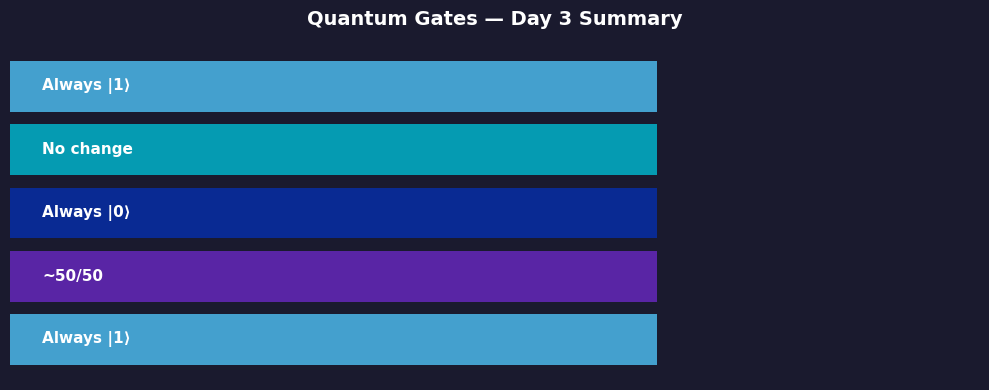

✅ Gates summary saved!


In [7]:
# Cell 13 — Gates Summary Visualization
os.makedirs("../results", exist_ok=True)

gates = ['X Gate', 'H Gate\n(once)', 'H Gate\n(twice)', 'Z Gate', 'H+Z+H']
observations = ['Always |1⟩', '~50/50', 'Always |0⟩', 'No change', 'Always |1⟩']
colors = ['#4fc3f7', '#6929C4', '#052FAD', '#00BCD4', '#4fc3f7']

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(gates, [1,1,1,1,1], color=colors, alpha=0.8)

for i, obs in enumerate(observations):
    ax.text(0.05, i, obs, va='center', fontsize=11,
            color='white', fontweight='bold')

ax.set_xlim(0, 1.5)
ax.axis('off')
ax.set_title('Quantum Gates — Day 3 Summary',
             fontsize=14, fontweight='bold', color='white',
             pad=15)

fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

plt.tight_layout()
plt.savefig("../results/gates_results.png",
            facecolor='#1a1a2e')
plt.show()
print("✅ Gates summary saved!")

Conclusion

| Gate | Input | Output | Key Property |
|------|-------|--------|--------------|
| X | \|0⟩ | \|1⟩ | Quantum NOT |
| H | \|0⟩ | \|+⟩ | Superposition |
| H·H | \|0⟩ | \|0⟩ | Self-inverse |
| Z | \|0⟩ | \|0⟩ | Phase flip |
| H+Z+H | \|0⟩ | \|1⟩ | Phase kickback |
| CNOT | \|10⟩ | \|11⟩ | Entanglement |
| Toffoli | \|110⟩ | \|111⟩ | Quantum AND |

## ✅ All 5 gates verified experimentally!
Every gate = a rotation on the Bloch Sphere.